<a href="https://colab.research.google.com/github/Asaf21S/constrained-flow-matching/blob/main/notebooks/flow_matching_mnist_HardFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
!pip install torchcfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher, ExactOptimalTransportConditionalFlowMatcher
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import math

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Dataset

In [4]:
def get_mnist_loader(batch_size=128):
    transform = transforms.Compose([
        transforms.Pad(2),  # 28x28 -> 32x32
        transforms.ToTensor(),  # [0, 255] -> [0, 1]
        transforms.Normalize((0.5,), (0.5,))  # [0, 1] -> [-1, 1]
    ])

    dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)  # (tensor of size [batch, 1, 32, 32], gt digit)

In [5]:
dataloader = get_mnist_loader()

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 461kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.3MB/s]


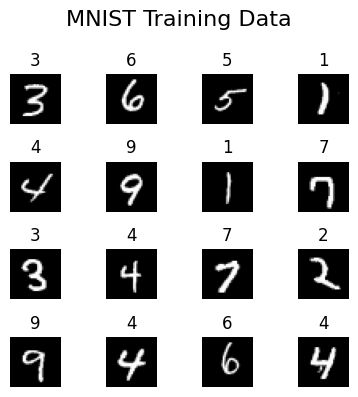

In [6]:
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 4, figsize=(4, 4))
fig.suptitle("MNIST Training Data", fontsize=16)

for i, ax in enumerate(axes.flat):
    # [-1, 1] -> [0, 1]
    img = (images[i] + 1) / 2
    img = img.clamp(0, 1)

    ax.imshow(img.squeeze(0).cpu().numpy(), cmap='gray')

    ax.set_title(f"{labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Model definition

In [7]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [8]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_channels)
        )

        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.residual = nn.Identity()
        if in_channels != out_channels:
            self.residual = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x, t_emb):
        h = x
        h = self.norm1(h)
        h = self.act1(h)
        h = self.conv1(h)

        # Add time
        t_vec = self.time_proj(t_emb)[:, :, None, None]
        h = h + t_vec

        h = self.norm2(h)
        h = self.act2(h)
        h = self.conv2(h)

        return h + self.residual(x)

In [9]:
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # Strided conv reduces size by 2
        self.op = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)

In [10]:
class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1)

    def forward(self, x):
        return self.conv(self.up(x))

In [11]:
class ImprovedUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_c=64):
        super().__init__()
        time_dim = base_c * 4

        # Time Embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_c),
            nn.Linear(base_c, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        # --- Encoder ---
        self.inc = nn.Conv2d(in_channels, base_c, 3, padding=1)

        # Level 1 (32x32)
        self.down1 = ResBlock(base_c, base_c, time_dim)
        self.ds1 = Downsample(base_c)

        # Level 2 (16x16)
        self.down2 = ResBlock(base_c, base_c * 2, time_dim)
        self.ds2 = Downsample(base_c * 2)

        # Level 3 (8x8)
        self.down3 = ResBlock(base_c * 2, base_c * 4, time_dim)
        self.ds3 = Downsample(base_c * 4)

        # --- Bottleneck (4x4) ---
        self.bot1 = ResBlock(base_c * 4, base_c * 4, time_dim)
        self.bot2 = ResBlock(base_c * 4, base_c * 4, time_dim)

        # --- Decoder ---
        # Level 3 (8x8)
        self.us3 = Upsample(base_c * 4, base_c * 4) # 4 -> 8
        self.dec3 = ResBlock(base_c * 8, base_c * 2, time_dim) # Input is 4c + 4c (skip) = 8c

        # Level 2 (16x16)
        self.us2 = Upsample(base_c * 2, base_c * 2) # 8 -> 16
        self.dec2 = ResBlock(base_c * 4, base_c, time_dim) # Input is 2c + 2c (skip) = 4c

        # Level 1 (32x32)
        self.us1 = Upsample(base_c, base_c) # 16 -> 32
        self.dec1 = ResBlock(base_c * 2, base_c, time_dim) # Input is c + c (skip) = 2c

        self.outc = nn.Conv2d(base_c, out_channels, 1)

    def forward(self, t, x):
        t = self.time_mlp(t)

        # Encoder
        x1 = self.inc(x)             # 32x32
        x1 = self.down1(x1, t)       # 32x32 (Skip connection 1)

        x2 = self.ds1(x1)            # 16x16
        x2 = self.down2(x2, t)       # 16x16 (Skip connection 2)

        x3 = self.ds2(x2)            # 8x8
        x3 = self.down3(x3, t)       # 8x8 (Skip connection 3)

        x4 = self.ds3(x3)            # 4x4
        x4 = self.bot1(x4, t)        # 4x4
        x4 = self.bot2(x4, t)

        # Decoder
        u3 = self.us3(x4)            # 8x8
        u3 = torch.cat([u3, x3], dim=1) # Concat (4c + 4c)
        u3 = self.dec3(u3, t)        # -> 2c

        u2 = self.us2(u3)            # 16x16
        u2 = torch.cat([u2, x2], dim=1) # Concat (2c + 2c)
        u2 = self.dec2(u2, t)        # -> c

        u1 = self.us1(u2)            # 32x32
        u1 = torch.cat([u1, x1], dim=1) # Concat (c + c)
        u1 = self.dec1(u1, t)

        return self.outc(u1)

# Train loop

In [12]:
# Use cached model instead:
model = ImprovedUNet().to(device)
state_dict = torch.load("mnist_unet.pth", map_location=device)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [ ]:
# Settings
model = ImprovedUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=0.0)
epochs = 20

loss_list = []

In [ ]:
for epoch in tqdm(range(epochs)):
    epoch_loss = []
    for i, (images, labels) in tqdm(enumerate(dataloader), total=len(dataloader)):
        optimizer.zero_grad()

        x1 = images.to(device) # real image
        x0 = torch.randn_like(x1).to(device) # noise

        t, xt, real_vt = FM.sample_location_and_conditional_flow(x0, x1)
        pred_vt = model(t, xt)
        loss = torch.mean((pred_vt - real_vt) ** 2)
        epoch_loss.append(loss.item())

        loss.backward()
        optimizer.step()

    loss_list.extend(epoch_loss)
    print(np.mean(epoch_loss))

    if epoch + 1 % 10 == 0:
        torch.save(model.state_dict(), f"mnist_model_epoch_{epoch}.pth")

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/468 [00:00<?, ?it/s]

0.49029398238302296


  0%|          | 0/468 [00:00<?, ?it/s]

0.15836149208948144


...

0.10143024436174294


  0%|          | 0/468 [00:00<?, ?it/s]

0.10164916900615407


  0%|          | 0/468 [00:00<?, ?it/s]

0.10027979521287812


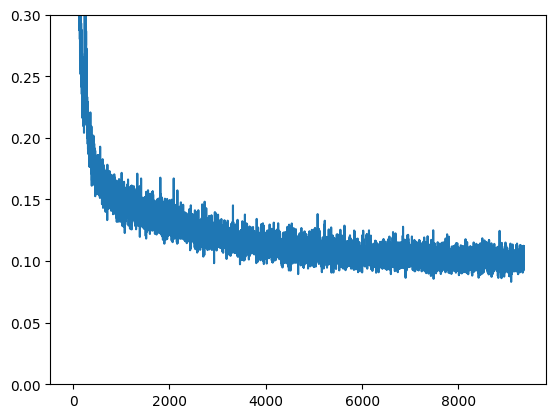

In [ ]:
plt.plot(loss_list)
plt.ylim(0, 0.3)
plt.show()

In [ ]:
torch.save(model.state_dict(), "mnist_unet.pth")

# Visualization Helper Function

In [38]:
def show_mnist_grid(sampled_data, title: str, add_middle_rect: bool = False):
    grid_img = torchvision.utils.make_grid(sampled_data, nrow=4, padding=0)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(grid_img.permute(1, 2, 0).cpu())
    ax.set_title(title, fontsize=14)

    ax.axis('off')

    if add_middle_rect:
        for i in range(16):
            row = i // 4
            col = i % 4

            rect_x = col * 32 + 12.5
            rect_y = row * 32 + 12.5

            rect = plt.Rectangle((rect_x, rect_y), 6, 6, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

    plt.show()

In [ ]:
def visualize_trajectory_snapshots(trajectory, num_snapshots=10):
    """
    trajectory: numpy array of shape [steps, 1, 32, 32]
    """
    steps = len(trajectory)
    # Pick indices evenly spaced from 0 to end
    indices = np.linspace(0, steps - 1, num_snapshots).astype(int)

    fig, axes = plt.subplots(1, num_snapshots, figsize=(15, 3))

    for i, idx in enumerate(indices):
        # 1. Get image and remove channel dim: [1, 32, 32] -> [32, 32]
        img = trajectory[idx].squeeze()

        # 2. Un-normalize for display: [-1, 1] -> [0, 1]
        img = (img + 1) / 2
        img = np.clip(img, 0, 1)

        # 3. Plot
        axes[i].imshow(img, cmap='gray')

        # Calculate time t (approx)
        t = idx / (steps - 1)
        axes[i].set_title(f"t={t:.1f}", fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f"Generation Trajectory (Digit Emergence)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

def animate_trajectory(trajectory):
    """
    Creates an animation from the trajectory array.
    """
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis('off')

    # Setup the initial empty plot
    # We un-normalize the first frame
    img_data = (trajectory[0].squeeze() + 1) / 2
    img_data = np.clip(img_data, 0, 1)
    im = ax.imshow(img_data, cmap='gray', animated=True)
    title = ax.set_title("t=0.00")

    def update(frame_idx):
        # Update image data
        img = trajectory[frame_idx].squeeze()
        img = (img + 1) / 2
        img = np.clip(img, 0, 1)

        im.set_array(img)

        # Update title
        t = frame_idx / (len(trajectory) - 1)
        title.set_text(f"t={t:.2f}")
        return im, title

    # Create animation
    ani = animation.FuncAnimation(
        fig, update, frames=len(trajectory), interval=50, blit=True
    )

    plt.close() # Prevent double display in notebooks
    return ani

# Data sampler

In [39]:
def sample_mnist(model, n_samples, steps=100):
    model.eval()
    x = torch.randn(n_samples, 1, 32, 32).to(device)
    dt = 1.0 / steps

    traj = [x[0].clone().cpu()]
    with torch.no_grad():
        for i in range(steps):
            t = torch.ones(n_samples).to(device) * (i * dt)
            v = model(t, x)
            x = x + v * dt
            traj.append(x[0].clone().cpu())

    # [-1, 1] -> [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x.cpu(), torch.stack(traj).numpy()  # traj size [steps, 1, 32, 32]

In [40]:
sampled_data, traj = sample_mnist(model, n_samples=16)

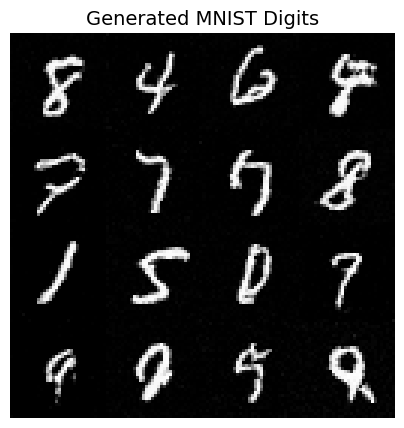

In [41]:
show_mnist_grid(sampled_data, "Generated MNIST Digits")

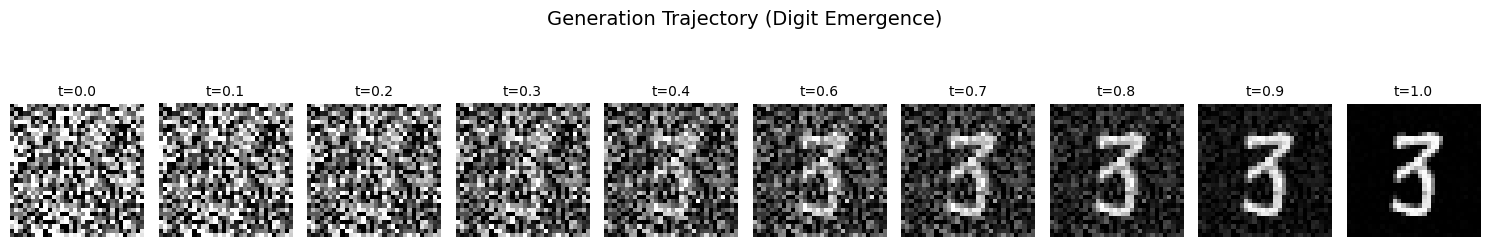

In [17]:
visualize_trajectory_snapshots(traj)

In [19]:
ani = animate_trajectory(traj)
HTML(ani.to_jshtml())

# Data sampler - ECI

In [42]:
def sample_mnist_eci(model, n_samples, constraint_fn, steps=100, correction_loops=1):
    model.eval()
    x = torch.randn(n_samples, 1, 32, 32).to(device)
    x0 = x.clone()
    dt = 1.0 / steps

    traj = [x[0].clone().cpu()]
    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.ones(n_samples).to(device) * t
            for m in range(correction_loops):  # applying the eci projections m times every step
                # Extrapolation
                v = model(t_batch, x)
                x1_pred = x + (1 - t) * v

                # Correction
                x1_corrected = constraint_fn(x1_pred)

                # Interpolation
                x_new = (1 - t) * x0 + t * x1_corrected
                if m < correction_loops - 1:
                    x = x_new

            next_t = t + dt
            x = (1 - next_t) * x0 + next_t * x1_corrected
            traj.append(x[0].clone().cpu())

    # [-1, 1] -> [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x.cpu(), torch.stack(traj).numpy()  # traj size [steps, 1, 32, 32]

### Black Hole Constraint

In [43]:
def center_black_hole_constraint(x1_pred):
    """
    Forces the center 6x6 pixels to be Black (-1).
    Image size: 32x32.
    Center indices: 13 to 19 (6 pixels).
    """
    x1_fixed = x1_pred.clone()
    x1_fixed[:, :, 13:19, 13:19] = -1.0

    return x1_fixed

In [44]:
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=center_black_hole_constraint, correction_loops=1)

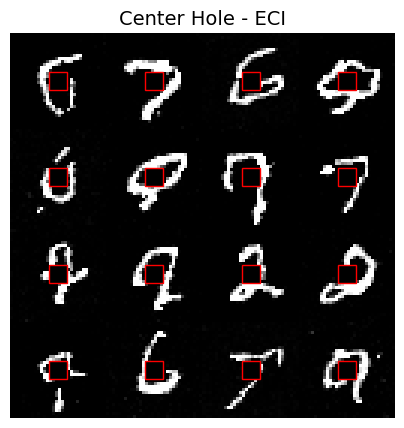

In [45]:
show_mnist_grid(sampled_data_eci, "Center Hole - ECI", add_middle_rect=True)

### Total Ink Constraint

In [24]:
def total_ink_constraint(x1_pred, target_ink=100.0):
    """
    Forces the total 'ink' (sum of pixel intensities) to be exactly K.
    1. Converts [-1, 1] to [0, 1] space.
    2. Scales the intensities to match the target sum.
    3. Converts back to [-1, 1].
    """
    x1_fixed = x1_pred.clone()

    ink_values = (x1_fixed + 1) / 2
    current_ink = ink_values.sum(dim=(1, 2, 3))  # size [batch]
    current_ink = torch.clamp(current_ink, min=1e-5)

    scale_factor = (target_ink / current_ink).view(-1, 1, 1, 1)
    new_ink = ink_values * scale_factor
    x1_fixed = new_ink * 2 - 1
    return torch.clamp(x1_fixed, -1, 1)

In [46]:
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=lambda x: total_ink_constraint(x, target_ink=60.0), correction_loops=1)

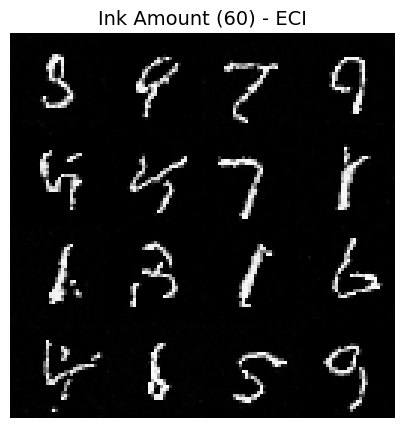

In [48]:
show_mnist_grid(sampled_data_eci, "Ink Amount (60) - ECI")

In [49]:
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=lambda x: total_ink_constraint(x, target_ink=150.0), correction_loops=1)

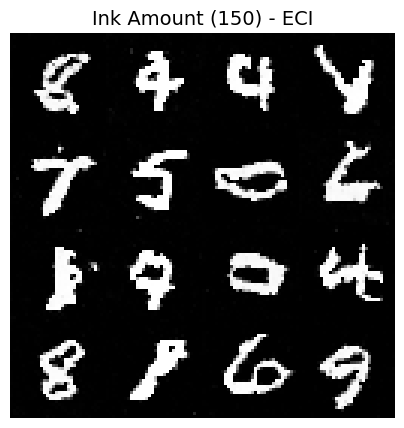

In [50]:
show_mnist_grid(sampled_data_eci, "Ink Amount (150) - ECI")

### Symmetry Constraint

In [51]:
def symmetry_constraint(x1_pred):
    """
    Forces Vertical Symmetry (Left side mirrors Right side).
    Formula: x = (x + flip_lr(x)) / 2
    """
    x_flipped = torch.flip(x1_pred, dims=[-1])
    x_fixed = (x1_pred + x_flipped) / 2.0
    return x_fixed

In [52]:
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=symmetry_constraint, correction_loops=1)

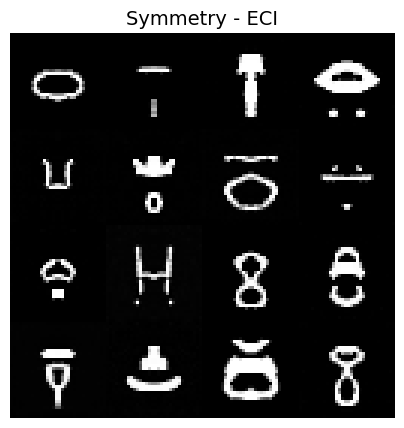

In [53]:
show_mnist_grid(sampled_data_eci, "Symmetry - ECI")

### Specific Digit Constraint

In [54]:
def get_digit_subspace(target_digit, n_components=10, device='cuda'):
    """
    Calculates the PCA basis for a specific digit using the exact same
    preprocessing as the training loader.
    """
    print(f"--- Computing Subspace for Digit {target_digit} ---")

    transform = transforms.Compose([
        transforms.Pad(2),              # 28x28 -> 32x32
        transforms.ToTensor(),          # [0, 255] -> [0, 1]
        transforms.Normalize((0.5,), (0.5,)) # [0, 1] -> [-1, 1]
    ])

    dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

    idx = (dataset.targets == target_digit).nonzero(as_tuple=True)[0]
    print(f"Found {len(idx)} examples of digit {target_digit}")

    subset = torch.utils.data.Subset(dataset, idx)
    loader = torch.utils.data.DataLoader(subset, batch_size=1000, shuffle=False)

    all_images = []
    for x, _ in loader:
        all_images.append(x)

    data_tensor = torch.cat(all_images, dim=0).to(device)  # [N, 1, 32, 32]

    B, C, H, W = data_tensor.shape
    flat_data = data_tensor.view(B, -1)  # [N, 1024]

    # Perform PCA (SVD)
    mean_vec = torch.mean(flat_data, dim=0)

    centered_data = flat_data - mean_vec

    U, S, V = torch.pca_lowrank(centered_data, q=n_components)

    # V is [1024, n_components]
    basis_vectors = V.T

    print(f"PCA Computed. Basis shape: {basis_vectors.shape}")
    return mean_vec, basis_vectors

In [55]:
def visualize_subspace(mean, basis):
    # [-1, 1] -> [0, 1]
    def to_img(t):
        return (t.view(32, 32).cpu() + 1) / 2

    plt.figure(figsize=(10, 4))

    # Plot Mean
    plt.subplot(1, 6, 1)
    plt.title("Mean digit")
    plt.imshow(to_img(mean), cmap='gray')
    plt.axis('off')

    # Plot top 5 Variations
    for i in range(5):
        plt.subplot(1, 6, i+2)
        plt.title(f"Comp {i+1}")
        # Components are directions
        plt.imshow(basis[i].view(32, 32).cpu(), cmap='bwr') # Blue-White-Red colormap
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [56]:
def pca_constraint_fn(x1_pred, mean_digit, basis_vectors):
    """
    Projector: Forces x1 to lie on the linear subspace of the target digit.
    Math: x_proj = Mean + V * V^T * (x - Mean)
    """
    B, C, H, W = x1_pred.shape

    x_flat = x1_pred.view(B, -1)  # [Batch, 1024]
    x_centered = x_flat - mean_digit

    scores = torch.matmul(x_centered, basis_vectors.T)
    x_recon = torch.matmul(scores, basis_vectors)
    x_out = x_recon + mean_digit

    return x_out.view(B, C, H, W)

In [57]:
n_components = 20
mean_vec_list = []
basis_vectors_list = []
for digit in range(10):
    mean_vec, basis_vectors = get_digit_subspace(target_digit=digit, n_components=n_components, device=device)
    mean_vec_list.append(mean_vec)
    basis_vectors_list.append(basis_vectors)

--- Computing Subspace for Digit 0 ---
Found 5923 examples of digit 0
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 1 ---
Found 6742 examples of digit 1
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 2 ---
Found 5958 examples of digit 2
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 3 ---
Found 6131 examples of digit 3
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 4 ---
Found 5842 examples of digit 4
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 5 ---
Found 5421 examples of digit 5
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 6 ---
Found 5918 examples of digit 6
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 7 ---
Found 6265 examples of digit 7
PCA Computed. Basis shape: torch.Size([20, 1024])
--- Computing Subspace for Digit 8 ---
F

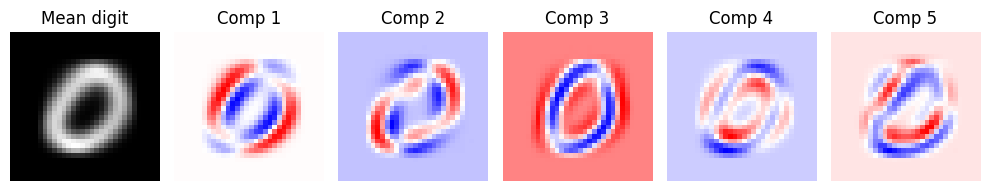

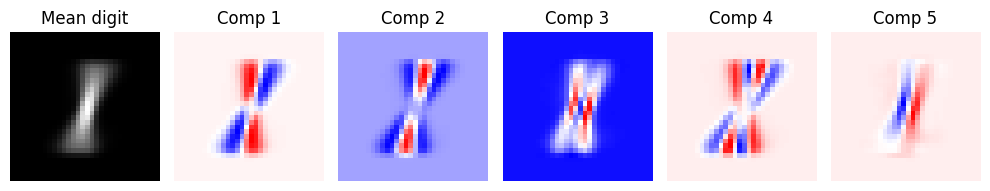

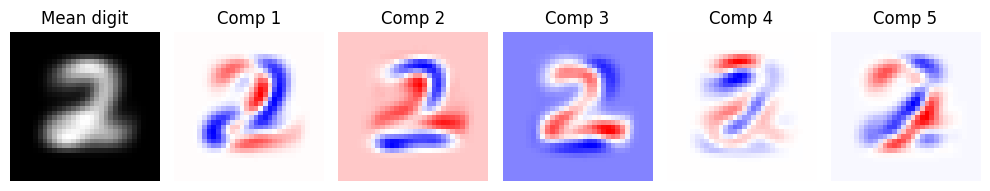

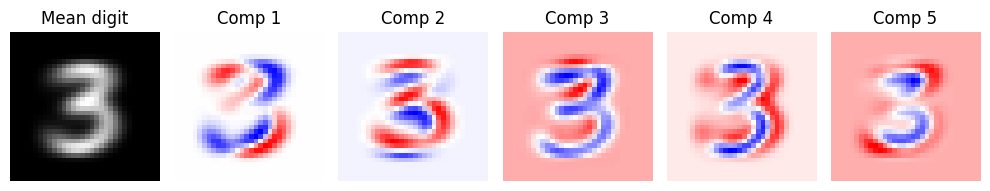

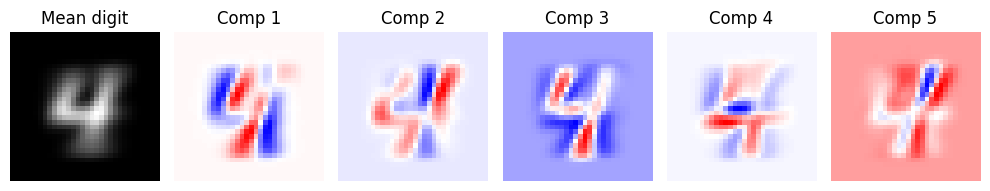

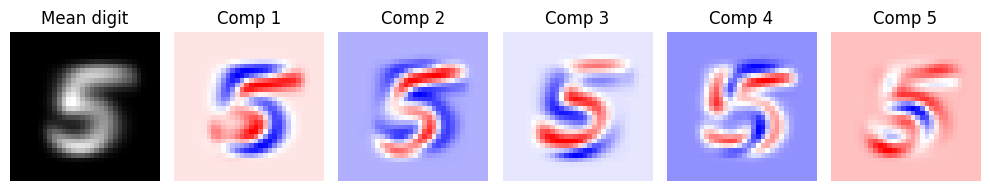

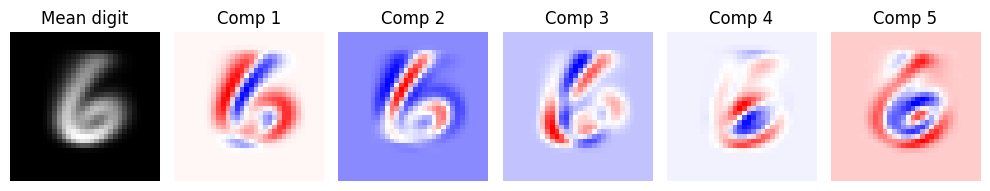

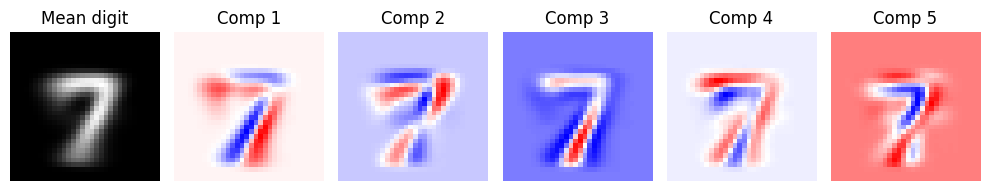

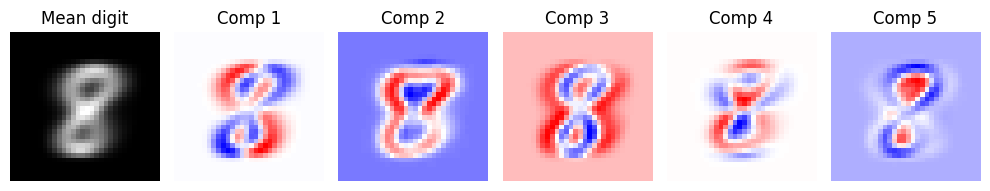

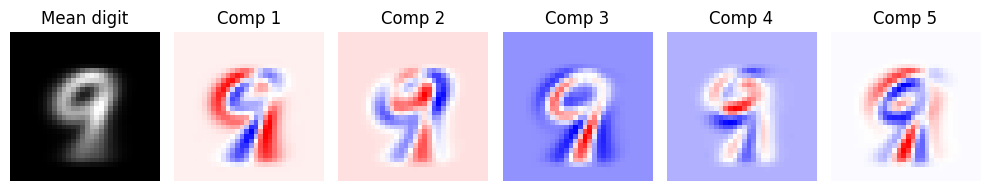

In [58]:
for digit in range(10):
    mean_vec = mean_vec_list[digit]
    basis_vectors = basis_vectors_list[digit]
    visualize_subspace(mean_vec, basis_vectors)

In [59]:
digit = 3
sampled_data_eci, traj_eci = sample_mnist_eci(model, n_samples=16, constraint_fn=lambda x: pca_constraint_fn(x, mean_vec_list[digit], basis_vectors_list[digit]), correction_loops=1)

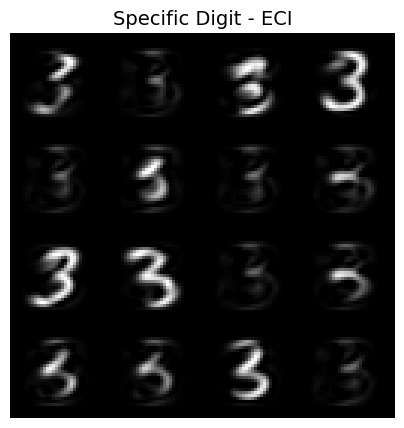

In [60]:
show_mnist_grid(sampled_data_eci, "Specific Digit - ECI")

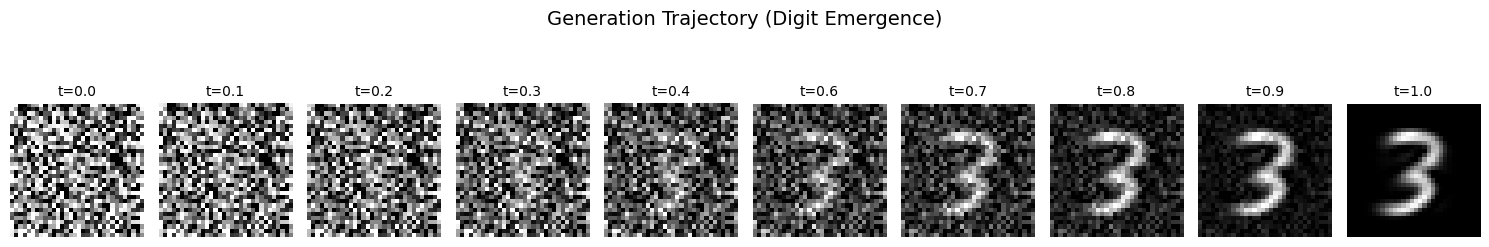

In [39]:
visualize_trajectory_snapshots(traj_eci)

In [61]:
sampled_data_eci_list = []
for digit in range(10):
    sampled_data_eci_digit, _ = sample_mnist_eci(model, n_samples=10, constraint_fn=lambda x: pca_constraint_fn(x, mean_vec_list[digit], basis_vectors_list[digit]), correction_loops=1)
    sampled_data_eci_list.append(sampled_data_eci_digit)

In [64]:
def show_all_digits_grid(dampled_data_list, title: str):
    all_samples = torch.cat(dampled_data_list, dim=0).detach().cpu()

    grid_img = torchvision.utils.make_grid(all_samples, nrow=10, padding=0)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(title, fontsize=20, pad=20)
    ax.axis('off')
    ax.imshow(grid_img.permute(1, 2, 0).numpy())

    # Add the row labels using global coordinates
    for digit_idx in range(10):
        y_center = digit_idx * 32 + 16
        ax.text(-10, y_center, f"Digit {digit_idx}", fontsize=14, ha='right', va='center', fontweight='bold')

    plt.show()

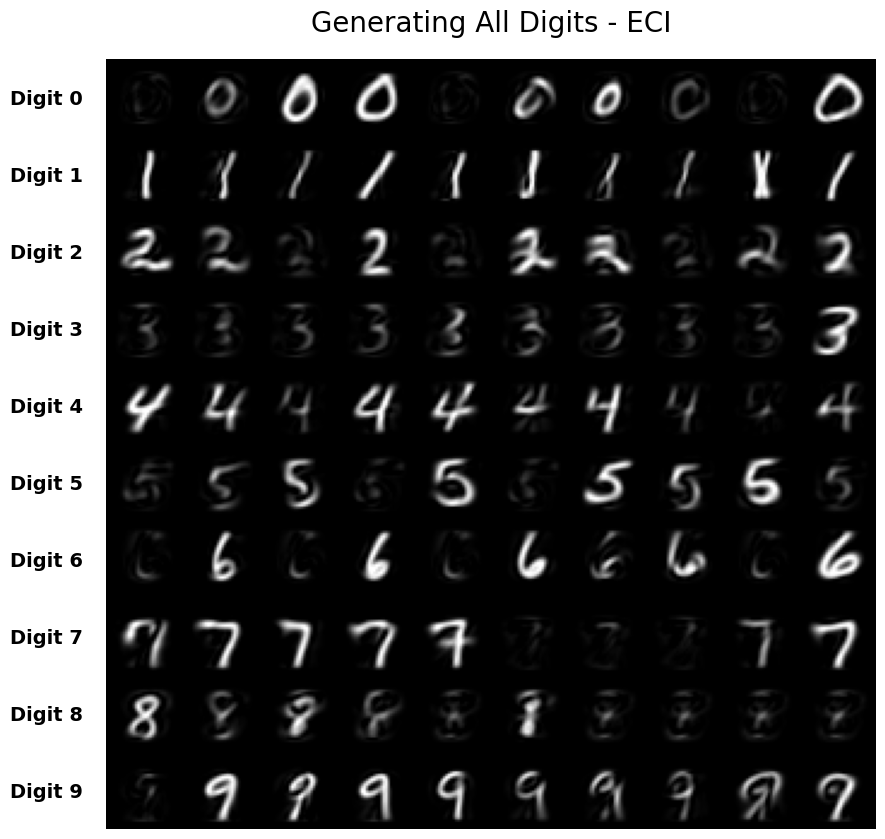

In [66]:
show_all_digits_grid(sampled_data_eci_list, "Generating All Digits - ECI")

# HardFlow

In [67]:
def sample_mnist_hardflow(model, n_samples, loss_fn, steps=100, guidance_scale=5.0):
    """
    HardFlow-style sampling for high-dimensional image data (MNIST).
    """
    model.eval()

    x = torch.randn(n_samples, 1, 32, 32).to(device)
    dt = 1.0 / steps

    traj = [x[0].clone().cpu()]

    for i in range(steps):
        t_scalar = i * dt
        t_batch = torch.ones(n_samples).to(device) * t_scalar

        x = x.detach().requires_grad_(True)

        v = model(t_batch, x)

        # predict the destination
        x1_hat = x + (1 - t_scalar) * v

        # calculate the constraint loss on the predicted destination
        loss = loss_fn(x1_hat).sum()

        # calculate the gradient w.r.t x_t
        grad = torch.autograd.grad(loss, x)[0]

        # apply guidance - subtract the gradient from the velocity to pull it towards lower loss
        v_guided = v - guidance_scale * grad

        x = x.detach() + v_guided.detach() * dt

        traj.append(x[0].clone().cpu())

    x_final = (x.clamp(-1, 1) + 1) / 2

    return x_final.cpu(), torch.stack(traj).numpy()

### Black Hole Constraint

In [68]:
def center_black_hole_loss(x1_hat):
    """
    Penalizes pixels in the center 6x6 region that are not Black (-1).
    Image size: 32x32.
    Center indices: 13 to 19 (6 pixels).
    """
    center_region = x1_hat[:, :, 13:19, 13:19]
    loss = (center_region + 1.0) ** 2
    return loss

In [69]:
sampled_data_hardflow, traj_hardflow = sample_mnist_hardflow(model, n_samples=16, loss_fn=center_black_hole_loss, guidance_scale=20.0)

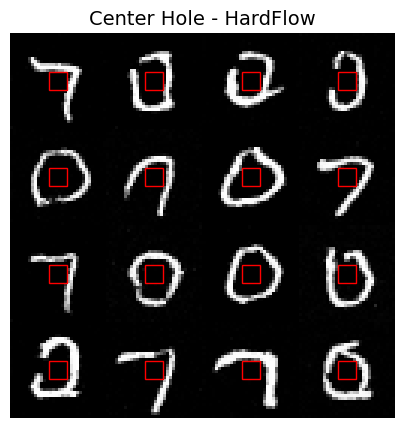

In [70]:
show_mnist_grid(sampled_data_hardflow, "Center Hole - HardFlow", add_middle_rect=True)

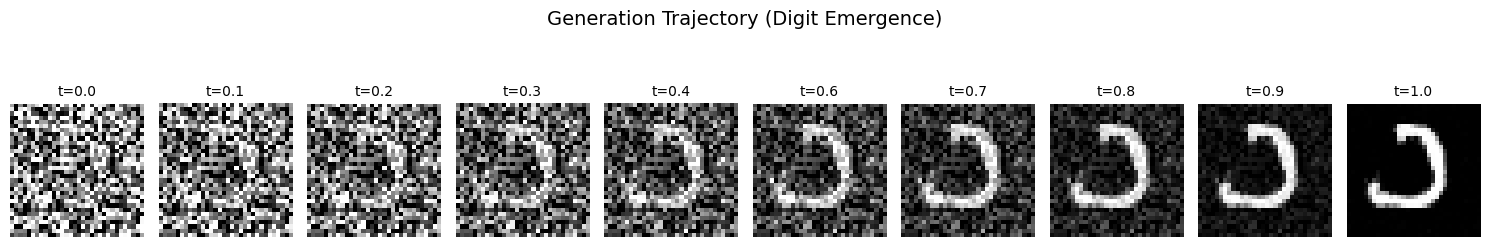

In [150]:
visualize_trajectory_snapshots(traj_hardflow)

### Total Ink Constraint

In [71]:
def total_ink_loss(x1_hat, target_ink=60.0):
    """
    Penalizes images whose total ink (sum of pixel intensities in [0, 1] space)
    deviates from the target_ink.
    """
    ink_values = (x1_hat + 1) / 2
    current_ink = ink_values.sum(dim=(1, 2, 3))
    loss = (current_ink - target_ink) ** 2
    return loss

In [72]:
sampled_data_hf, traj_hf = sample_mnist_hardflow(model, n_samples=16, loss_fn=lambda x: total_ink_loss(x, target_ink=60.0), guidance_scale=0.01)

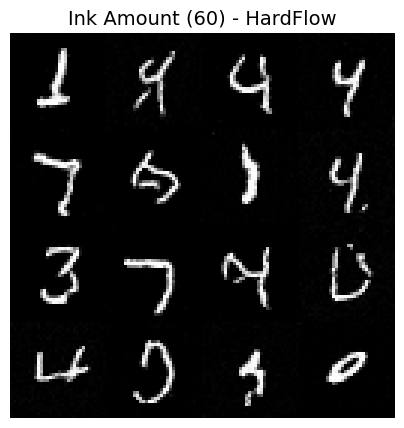

In [74]:
show_mnist_grid(sampled_data_hf, "Ink Amount (60) - HardFlow")

In [75]:
sampled_data_hf, traj_hf = sample_mnist_hardflow(model, n_samples=16, loss_fn=lambda x: total_ink_loss(x, target_ink=150.0), guidance_scale=0.01)

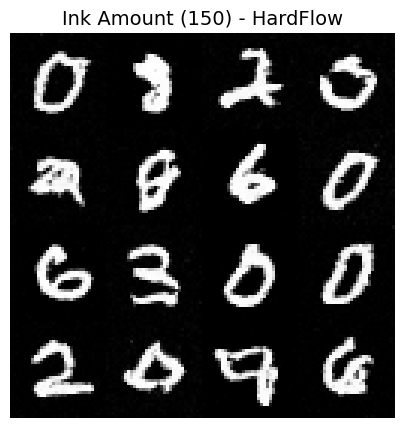

In [76]:
show_mnist_grid(sampled_data_hf, "Ink Amount (150) - HardFlow")

### Symmetry Constraint

In [77]:
def symmetry_loss(x1_hat):
    """
    Penalizes images that are not horizontally symmetric.
    Calculates the squared difference between the image and its flipped version.
    """
    x1_flipped = torch.flip(x1_hat, dims=[-1])
    loss = torch.abs(x1_hat - x1_flipped)
    return loss

In [80]:
sampled_data_hf, traj_hf = sample_mnist_hardflow(model, n_samples=16, loss_fn=symmetry_loss, guidance_scale=10.0)

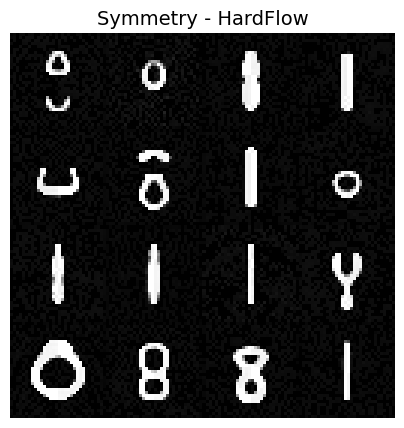

In [81]:
show_mnist_grid(sampled_data_hf, "Symmetry - HardFlow")

### Specific Digit Constraint

In [82]:
def pca_subspace_loss(x1_hat, mean_digit, basis_vectors):
    """
    Penalizes the orthogonal distance between the predicted image
    and the PCA subspace of the target digit.
    """
    B, C, H, W = x1_hat.shape

    x_flat = x1_hat.view(B, -1)
    x_centered = x_flat - mean_digit

    scores = torch.matmul(x_centered, basis_vectors.T)
    x_recon = torch.matmul(scores, basis_vectors)

    x_proj = x_recon + mean_digit
    x_proj = x_proj.view(B, C, H, W)

    loss = (x1_hat - x_proj) ** 2

    return loss

In [83]:
digit = 3
mean_vec = mean_vec_list[digit]
basis_vectors = basis_vectors_list[digit]

sampled_data_hf, traj_hf = sample_mnist_hardflow(model, n_samples=16, loss_fn=lambda x: pca_subspace_loss(x, mean_vec, basis_vectors), guidance_scale=10.0)

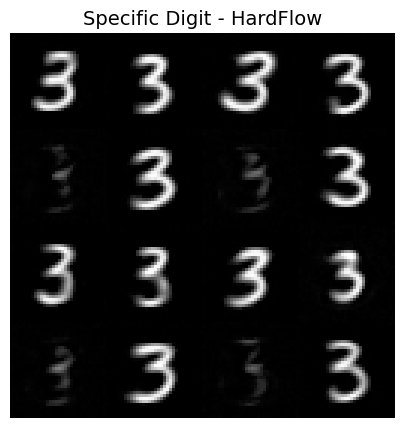

In [84]:
show_mnist_grid(sampled_data_hf, "Specific Digit - HardFlow")

In [85]:
sampled_data_hf_list = []
for digit in range(10):
    mean_vec = mean_vec_list[digit]
    basis_vectors = basis_vectors_list[digit]

    sampled_data_hf, _ = sample_mnist_hardflow(model, n_samples=10, loss_fn=lambda x: pca_subspace_loss(x, mean_vec, basis_vectors), guidance_scale=10.0)
    sampled_data_hf_list.append(sampled_data_hf)

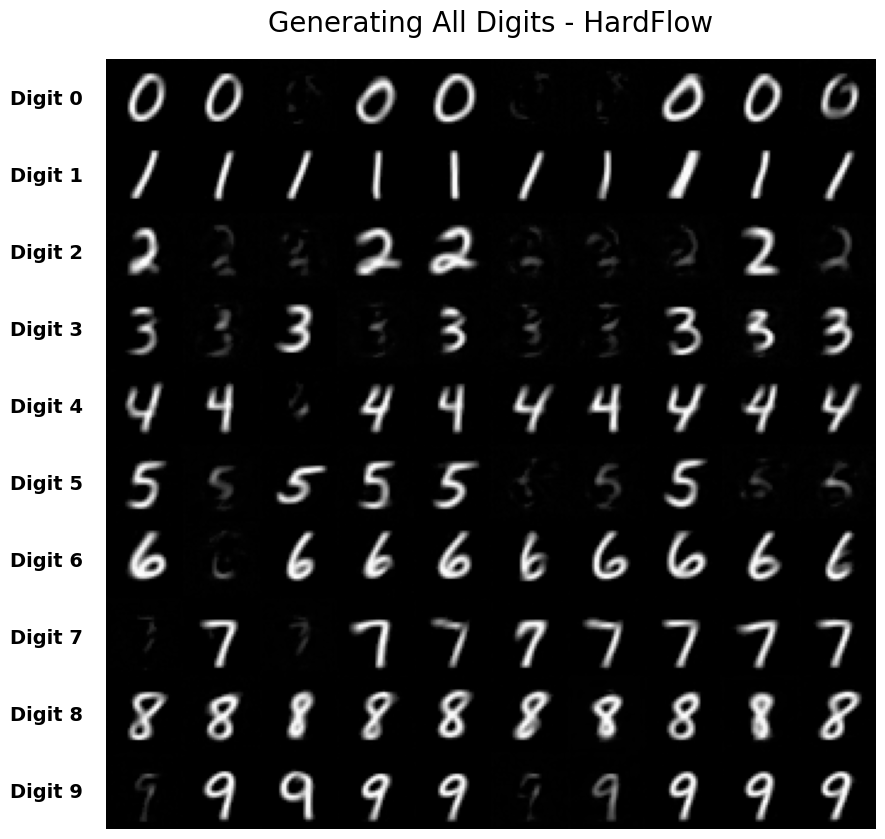

In [86]:
show_all_digits_grid(sampled_data_hf_list, "Generating All Digits - HardFlow")